In [1]:
import os
import numpy as np
import librosa
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [2]:
DATASET_PATH = "dataset_wav"

X = []
y = []

def extract_mfcc(file_path):
    audio, sr = librosa.load(file_path, sr=16000, mono=True)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    return np.mean(mfcc.T, axis=0)

for label in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, label)

    if not os.path.isdir(class_path):
        continue

    for file in os.listdir(class_path):
        file_path = os.path.join(class_path, file)

        try:
            mfcc = extract_mfcc(file_path)
            X.append(mfcc)
            y.append(label)
        except:
            print("skip:", file_path)

X = np.array(X)

c:\Users\SINTIAWATI\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [6]:
svm_model = SVC(kernel="linear", probability=True)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

In [7]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [8]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n===== {name} =====")
    
    acc = accuracy_score(y_true, y_pred)
    print("Accuracy:", acc)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=le.classes_,
                yticklabels=le.classes_,
                cmap="Blues")

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return acc


===== SVM =====
Accuracy: 0.9875

Classification Report:
              precision    recall  f1-score   support

        ayam       1.00      1.00      1.00         8
       bebek       1.00      1.00      1.00         8
       cicak       1.00      1.00      1.00         8
       gajah       1.00      1.00      1.00         8
     harimau       1.00      1.00      1.00         8
     kelinci       1.00      1.00      1.00         8
      kucing       1.00      1.00      1.00         8
       panda       1.00      1.00      1.00         8
        sapi       0.89      1.00      0.94         8
       zebra       1.00      0.88      0.93         8

    accuracy                           0.99        80
   macro avg       0.99      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



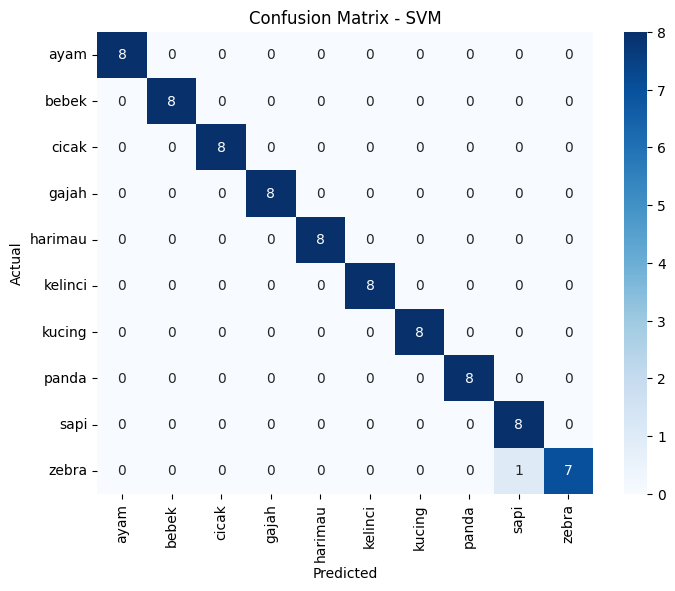


===== Random Forest =====
Accuracy: 0.925

Classification Report:
              precision    recall  f1-score   support

        ayam       1.00      0.88      0.93         8
       bebek       0.73      1.00      0.84         8
       cicak       0.88      0.88      0.88         8
       gajah       1.00      0.88      0.93         8
     harimau       0.89      1.00      0.94         8
     kelinci       1.00      0.75      0.86         8
      kucing       1.00      1.00      1.00         8
       panda       1.00      1.00      1.00         8
        sapi       0.88      0.88      0.88         8
       zebra       1.00      1.00      1.00         8

    accuracy                           0.93        80
   macro avg       0.94      0.93      0.93        80
weighted avg       0.94      0.93      0.93        80



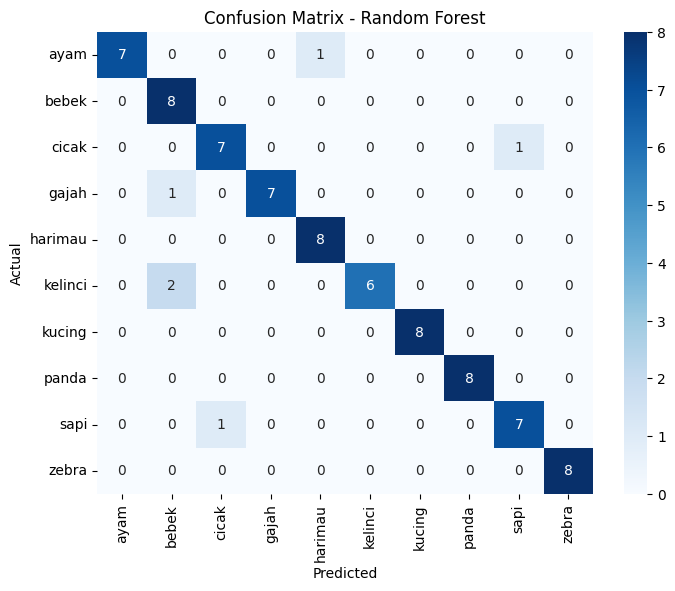

In [9]:
acc_svm = evaluate_model("SVM", y_test, y_pred_svm)
acc_rf = evaluate_model("Random Forest", y_test, y_pred_rf)

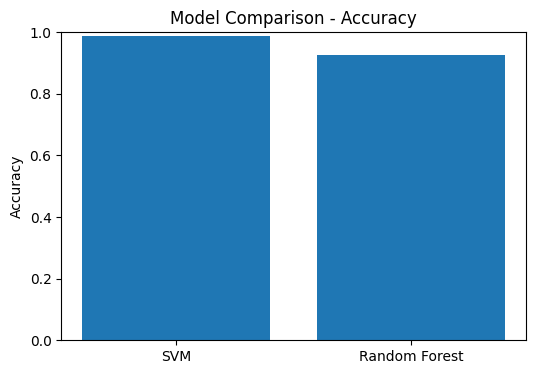

In [10]:
models = ["SVM", "Random Forest"]
accs = [acc_svm, acc_rf]

plt.figure(figsize=(6,4))
plt.bar(models, accs)
plt.title("Model Comparison - Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

In [11]:
best_model = rf_model if acc_rf > acc_svm else svm_model
best_name = "RandomForest" if acc_rf > acc_svm else "SVM"

print("Best Model:", best_name)

joblib.dump(best_model, "models/best_model.pkl")
joblib.dump(scaler, "models/best_scaler.pkl")
joblib.dump(le, "models/best_label_encoder.pkl")

Best Model: SVM


['models/best_label_encoder.pkl']